In [1]:
import sys
sys.path.append('..')
import numpy as np
import pickle 
import matplotlib.pyplot as plt
from utils import d_sl, years, dense_vegetation, compute_weights_lon
from sklearn.linear_model import LinearRegression
from delta_temp.tcrit import data_both_biomes
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from delta_temp.tcrit import data_both_biomes

d_ext = {"South America": "south_america",  "Africa": "africa", "SE Asia": "south_east_asia"}
d_ext = {value: key for key, value in d_ext.items()}
plt.rcParams.update({'font.size': 20})


0.018424954369827162
0.06395535183509748
0.010992587670347831


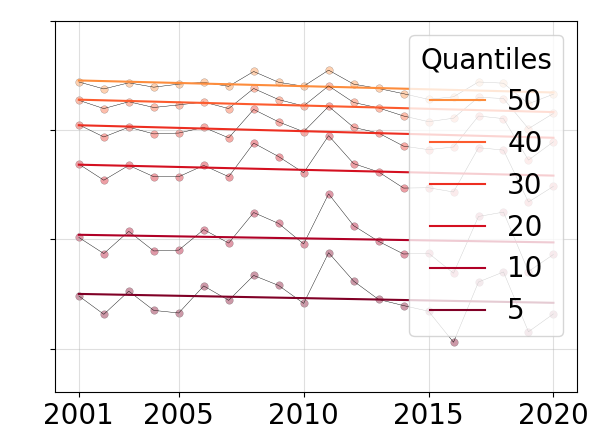

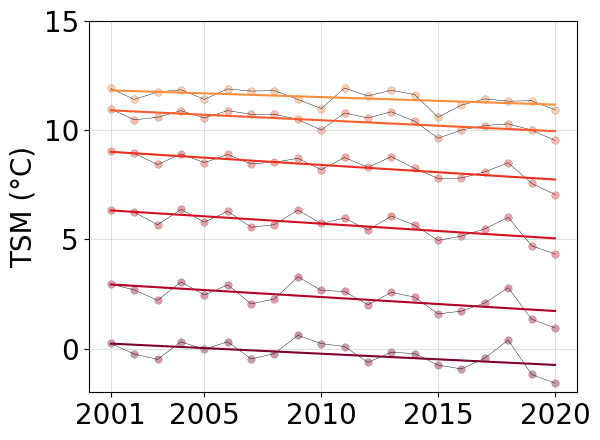

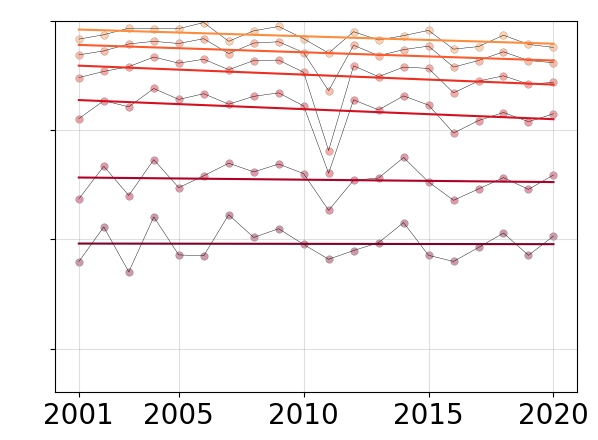

In [3]:
def f(sl, ext):
    outfile = f'/home/gaston/Projects/EcoStress/images/biomes/MeanDeltaT_min_max_removal_biomes_{"_".join(years)}_{ext}__maxperpixel_nanmax_fixed_allquantiles_tminv9_noterra_weightedquantiles__.pkl'
    with open(outfile, 'rb') as file:
        d_hansen_temp = pickle.load(file)
    return d_hansen_temp

points = np.linspace(0.5, 1.0, 6)
colormap = plt.get_cmap('YlOrRd')
colors = [colormap(point) for point in points]
quantiles = ['median', '0.6', '0.7', '0.8', '0.9', '0.95']


for key, sl in d_sl.items():
    ext = key
    key = d_ext[key]
    legend = key 
    fig = plt.figure()
    ax = fig.gca()
    ax.tick_params(axis='y')
    if key == "South America":
        ax.set_ylabel("TSM (°C)")
    linestyle = 'solid'
    d_hansen_temp = f(sl, ext)


    for color, quantile in zip(colors, quantiles):
        min_median = d_hansen_temp[quantile]
        min_median = -1 * np.asarray([min_median[i][0] for i in range(len(d_hansen_temp[quantile].keys())) if i % 12 == 11])
        min_median = min_median#[:-2]

        model_min_median = LinearRegression()
        X = np.arange(len(years)).reshape(-1, 1)
        model_min_median.fit(X, min_median)
        y = model_min_median.predict(X)
        if quantile == '0.9':
            pass
            # print(y[0]-y[1])
        coef = np.round(model_min_median.coef_[0], 4)
        x = np.arange(len(min_median))
        ax.plot(x, min_median, color='black', linewidth=0.3)
        ax.plot(years, y, color=color, linestyle=linestyle)
        plt.scatter(x, min_median, color=color, edgecolor='black', linewidth=.25, s=30, alpha=0.4)
        
        
        ax.set_xticks([0, 4, 9, 14, 19], [2001, 2005, 2010, 2015, 2020])
        if quantile == 'median':
            quantile = '0.5'
        ax.plot([], c=color, label=str(int(100*np.round(1-float(quantile), 2))))
        plt.ylim(-2,15)
        
    plt.grid(alpha=0.4)
    if key != "South America":
        plt.gca().yaxis.set_tick_params(labelcolor='none')
    if key == "SE Asia":
        
        ax.legend(title="Quantiles", loc=1)
    plt.tight_layout() 

[4.68039612 5.3339872  5.73793026 4.5907683  5.04904827 4.56026869
 5.77208084 5.36398741 4.19765474 4.67164215 4.85366043 5.9832509
 5.2356585  5.35410523 6.37134768 6.48419014 5.69510964 4.41100499
 7.02596843 7.85081462]


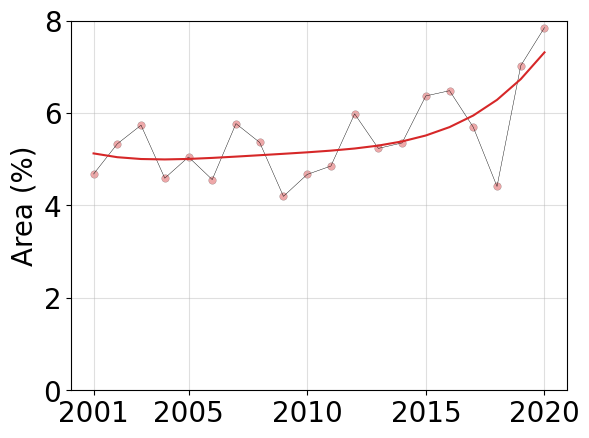

In [8]:
# Polynomial 
for key, sl in list(d_sl.items()):
    ext = key
    key = d_ext[key]
    if key != "South America":
        continue
    color = 'tab:red' 
    outfile = f"/data/gaston/ecostress/ecostress/worldwide/delta_Tmin_Tmodis{ext}_per_year_2001_2020_reversed_tminv6.npy"
    map = np.load(outfile)
    map = map.astype(float)
    map[~data_both_biomes[sl]] = np.nan
    weights_lon = compute_weights_lon(sl)
    above_threshold_map =  ((map > 0).transpose((2,0,1)) * weights_lon).transpose((1,2,0))
    above_threshold_map = above_threshold_map.astype(float)
    above_threshold_map[np.isnan(map)] = np.nan
    above_thresholds = np.nansum(np.nansum(above_threshold_map, axis=0) , axis=0)
    y = above_thresholds/np.sum(~np.isnan(map[...,0]) * weights_lon)*100 #ICI weights_lon

    model = LinearRegression()
    model = make_pipeline(PolynomialFeatures(4), Ridge(alpha=1e-5))
    X = np.arange(len(years)).reshape(-1, 1)
    model.fit(X, y)
    pred = model.predict(X)
    x = np.arange(len(y))
        
    fig = plt.figure()
    ax = fig.gca()
    ax.tick_params(axis='y')
    ax.set_ylabel("Area (%)")
    ax.plot(x, y, color='black', linewidth=0.3)
    ax.plot(years, pred, color=color, label=key)
    print(y)
    plt.scatter(x, y, color=color, edgecolor='black', linewidth=.25, s=30, alpha=0.4)


    ax.set_xticks([0, 4, 9, 14, 19], [2001, 2005, 2010, 2015, 2020])
    plt.ylim(0,8)
    plt.grid(alpha=0.4)
    

[2.38805753 3.12175168 2.24949462 2.86384909 3.01593745 1.91275485
 2.35699081 1.75126925 2.10083768 2.54036473 0.94815113 1.6662022
 2.29062632 2.46057086 2.93216332 4.62267137 1.93913641 1.65415057
 3.99910621 3.0706758 ]


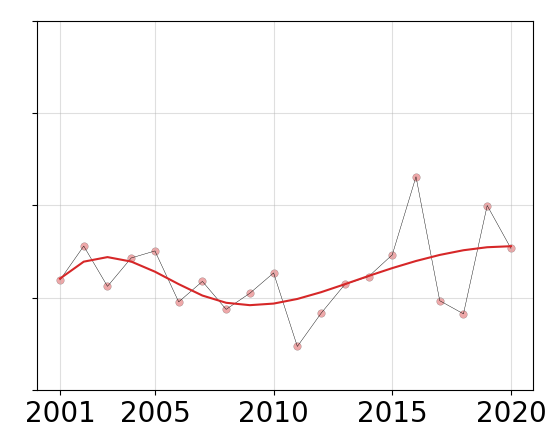

In [2]:
for key, sl in list(d_sl.items()):
    ext = key
    key = d_ext[key]
    if key != "SE Asia":
        continue
    color = 'tab:red'
    outfile = f"/data/gaston/ecostress/ecostress/worldwide/delta_Tmin_Tmodis{ext}_per_year_2001_2020_reversed_tminv6.npy"
    map = np.load(outfile)
    map = map.astype(float)
    map[~data_both_biomes[sl]] = np.nan
    weights_lon = compute_weights_lon(sl)
    above_threshold_map =  ((map > 0).transpose((2,0,1)) * weights_lon).transpose((1,2,0))
    above_threshold_map = above_threshold_map.astype(float)
    above_threshold_map[np.isnan(map)] = np.nan
    above_thresholds = np.nansum(np.nansum(above_threshold_map, axis=0) , axis=0)
    y = above_thresholds/np.sum(~np.isnan(map[...,0]) * weights_lon)*100 #ICI weights_lon

    model = LinearRegression()
    model = make_pipeline(PolynomialFeatures(4), Ridge(alpha=1e-5))
    model = make_pipeline(SplineTransformer(n_knots=4, degree=3), Ridge(alpha=1e-5))
    X = np.arange(len(years)).reshape(-1, 1)
    model.fit(X, y)
    pred = model.predict(X)
    x = np.arange(len(y))
        
    fig = plt.figure()
    ax = fig.gca()
    ax.tick_params(axis='y')
    ax.plot(x, y, color='black', linewidth=0.3)
    ax.plot(years, pred, color=color, label=key)
    plt.scatter(x, y, color=color, edgecolor='black', linewidth=.25, s=30, alpha=0.4)


    ax.set_xticks([0, 4, 9, 14, 19], [2001, 2005, 2010, 2015, 2020])
    plt.ylim(0,8)
    plt.grid(alpha=0.4)
    plt.gca().yaxis.set_tick_params(labelcolor='none')
    print(y)
    plt.gca().yaxis.set_tick_params(labelcolor='none')

[1.13039265 0.60392482 1.6870647  0.4327136  1.24529516 1.33852076
 0.37736669 1.13686038 1.04709156 1.31936478 1.16061432 1.30197261
 1.34430302 0.70556237 1.16849751 1.27342297 1.06611758 0.71006193
 1.43970853 1.47957476]


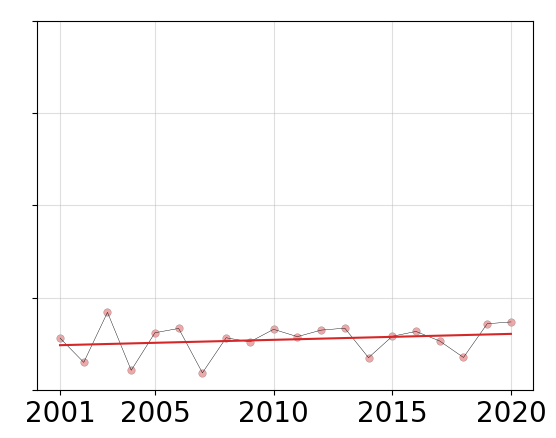

In [3]:


for key, sl in list(d_sl.items()):
    ext = key
    key = d_ext[key]
    if key != "Africa":
        continue
    color = 'tab:red' #d_color[key]
    outfile = f"/data/gaston/ecostress/ecostress/worldwide/delta_Tmin_Tmodis{ext}_per_year_2001_2020_reversed_tminv6.npy"
    map = np.load(outfile)
    map = map.astype(float)
    map[~data_both_biomes[sl]] = np.nan
    weights_lon = compute_weights_lon(sl)
    above_threshold_map =  ((map > 0).transpose((2,0,1)) * weights_lon).transpose((1,2,0))
    above_threshold_map = above_threshold_map.astype(float)
    above_threshold_map[np.isnan(map)] = np.nan
    above_thresholds = np.nansum(np.nansum(above_threshold_map, axis=0) , axis=0)
    y = above_thresholds/np.sum(~np.isnan(map[...,0]) * weights_lon)*100 #ICI weights_lon

    model = LinearRegression()
    X = np.arange(len(years)).reshape(-1, 1)
    model.fit(X, y)
    pred = model.predict(X)
    x = np.arange(len(y))
        
    fig = plt.figure()
    ax = fig.gca()
    ax.tick_params(axis='y')
    ax.plot(x, y, color='black', linewidth=0.3)
    ax.plot(years, pred, color=color, label=key)
    plt.scatter(x, y, color=color, edgecolor='black', linewidth=.25, s=30, alpha=0.4)


    ax.set_xticks([0, 4, 9, 14, 19], [2001, 2005, 2010, 2015, 2020])
    plt.ylim(0,8)
    plt.grid(alpha=0.4)
    print(y)
    plt.gca().yaxis.set_tick_params(labelcolor='none')
    